# 📝 Time Series - Machine Temperature

## 🌟 Highlights 
From this project "Time Series - Machine Temperature", the highlights with LSTM are addressed as:
- Chosen normal period: Before the 1st anomaly window
    - LSTM trained with chosen normal period (before the 1st anomaly window) flags too many normal points (high false positive)
      - precision = 0.2
      - recall = 0.5
      - f1 score = 0.29
    - The temperature level of chosen normal period seems relatively lower than the future baseline (the future normal period is higher than the chosen normal period in general)
- Chosen normal period: Between 2nd and 3rd anomaly window
  - LSTM trained with future baseline indeed can flag anomaly with fewer false positive
    - precision = 0.64
    - recall = 0.74
    - f1 score = 0.68
  - Anomaly pattern at 3rd anomaly window is different from 4th anomaly window, causing some false negative

## 🏭 Build Flow
- Import libraries
- Data cleaning & EDA
- Anomaly detection - LSTM
  - Set seed generator
  - Train and test split
  - Preprocessing the data
  - Create sequences
  - Convert to tensor
  - Build up LSTM model
  - Train LSTM with training set
  - Prediction
  - Threshold definition
  - Anomaly detection
  - Evaluation


### Import Libraries

In [329]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Reproducibility
import random

from itertools import product

# Show progress
from tqdm import tqdm

from scipy.stats import boxcox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import torch
import torch.nn as nn


### Data cleaning & EDA
- Data collection frequency
- Data type correction
- Separate datetime for convinient filter
- Missing data
- Add label data into dataframe
- Visualization

In [330]:
file = r'D:\coding\2026\time_series_analysis\realKnownCause\realKnownCause\machine_temperature_system_failure.csv'

df = pd.read_csv(file)
df.head(10)

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836
5,2013-12-02 21:40:00,78.710418
6,2013-12-02 21:45:00,80.269784
7,2013-12-02 21:50:00,80.272828
8,2013-12-02 21:55:00,80.353425
9,2013-12-02 22:00:00,79.486523


Data is collected every 5 mins

In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


timestamp column is not datetime data type 

In [332]:
# Change timestamp to datetime
df['time'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value,time
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00


In [333]:
# Separate year, month, date, hour, min out to columns (convenient for filter purpose)
df['year'] = df['time'].apply(lambda x: x.year)
df['month'] = df['time'].apply(lambda x: x.month)
df['day'] = df['time'].apply(lambda x: x.day)
df['hour'] = df['time'].apply(lambda x: x.hour)
df['minute'] = df['time'].apply(lambda x: x.minute)
df

,timestamp,value,time,year,month,day,hour,minute
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35
...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20


In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  object        
 1   value      22695 non-null  float64       
 2   time       22695 non-null  datetime64[ns]
 3   year       22695 non-null  int64         
 4   month      22695 non-null  int64         
 5   day        22695 non-null  int64         
 6   hour       22695 non-null  int64         
 7   minute     22695 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 1.4+ MB


In [335]:
print(df.shape)
df['value'].isnull().value_counts()

(22695, 8)


False    22695
Name: value, dtype: int64

No missing data

#### Add label data into dataframe
- Add label (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_labels.json))
- Add label window (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_windows.json))

In [336]:
anomaly_label = [
        "2013-12-11 06:00:00",
        "2013-12-16 17:25:00",
        "2014-01-28 13:55:00",
        "2014-02-08 14:30:00"
]

anomaly_window = [
        [
            "2013-12-10 06:25:00.000000",
            "2013-12-12 05:35:00.000000"
        ],
        [
            "2013-12-15 17:50:00.000000",
            "2013-12-17 17:00:00.000000"
        ],
        [
            "2014-01-27 14:20:00.000000",
            "2014-01-29 13:30:00.000000"
        ],
        [
            "2014-02-07 14:55:00.000000",
            "2014-02-09 14:05:00.000000"
        ]
    ]

In [337]:
df['anomaly_point'] = 0
df['anomaly_window'] = 0

'''
anomaly_point:
    1: anomaly; 0: normal
anomaly_window:
    1: anomaly_window; 0: normal
'''

for i in anomaly_label:
    df.loc[df['time'] == i, 'anomaly_point'] = 1

for start, end in anomaly_window:
    df.loc[((df['time'] >= start) & (df['time'] <= end)), 'anomaly_window'] = 1

df.head()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0


#### Visualization
- Visualize anomaly points
- Visualize anamaly window

In [338]:
df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_points
df_anomaly_windows = df[df['anomaly_window'] == 1]
df_anomaly_windows

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
2126,2013-12-10 06:25:00,53.886196,2013-12-10 06:25:00,2013,12,10,6,25,0,1
2127,2013-12-10 06:30:00,54.113727,2013-12-10 06:30:00,2013,12,10,6,30,0,1
2128,2013-12-10 06:35:00,53.514577,2013-12-10 06:35:00,2013,12,10,6,35,0,1
2129,2013-12-10 06:40:00,54.920342,2013-12-10 06:40:00,2013,12,10,6,40,0,1
2130,2013-12-10 06:45:00,55.162629,2013-12-10 06:45:00,2013,12,10,6,45,0,1
...,...,...,...,...,...,...,...,...,...,...
19794,2014-02-09 13:45:00,91.330425,2014-02-09 13:45:00,2014,2,9,13,45,0,1
19795,2014-02-09 13:50:00,89.886941,2014-02-09 13:50:00,2014,2,9,13,50,0,1
19796,2014-02-09 13:55:00,88.997810,2014-02-09 13:55:00,2014,2,9,13,55,0,1
19797,2014-02-09 14:00:00,90.408573,2014-02-09 14:00:00,2014,2,9,14,0,0,1


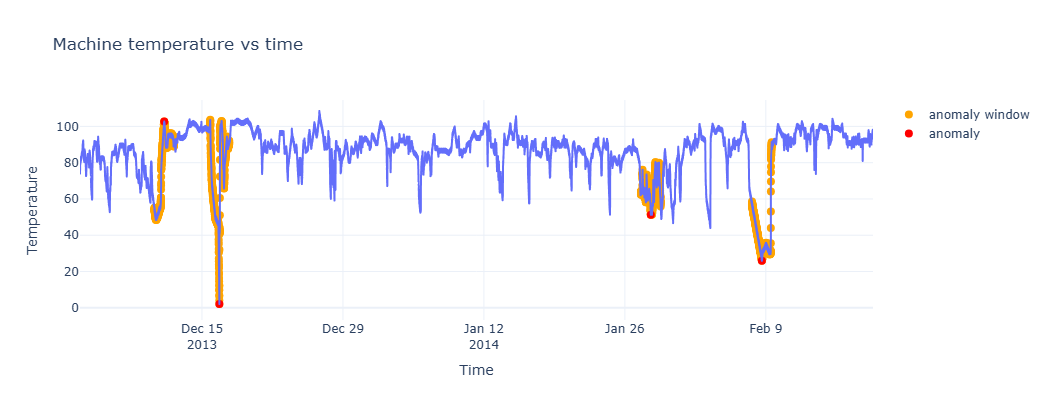

In [339]:
# Visualize line plot - temperature vs time
fig = px.line(df,
        x='time',
        y='value',
        width=1000,
        height=400,
        labels={'time': 'Time', 'value': 'Temperature'},
        template='plotly_white',
        title='Machine temperature vs time')

df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_windows = df[df['anomaly_window'] == 1]

fig.add_trace(go.Scatter(x=df_anomaly_windows['time'],
                         y=df_anomaly_windows['value'],
                         mode='markers',
                         marker=dict(size=8,color='orange',symbol='circle'),
                         name='anomaly window'
                        )
             )

fig.add_trace(go.Scatter(x=df_anomaly_points['time'], 
                         y=df_anomaly_points['value'],
                         mode='markers',
                         marker=dict(size=8,color='red',symbol='circle'),
                         name='anomaly'
                        )
             )


fig.show()

# '''
# This is the matplotlib version for reporting
# plt.figure(figsize=(16, 4.5))
# plt.plot(df['time'], df['value'])
# plt.xlabel('Time')
# plt.ylabel('Temperature')
# plt.xticks(fontsize=8)
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=6))
# plt.grid(True)
# plt.title('Machine temperature over time')
# plt.show()
# '''

Visualize anomalies and windows in the plot
- It is obvious to visually know 2nd and 4th as anomaly point; 1st and 3rd are less straightforward
- Window covers points before and after anomalies. Might be a hint of detection

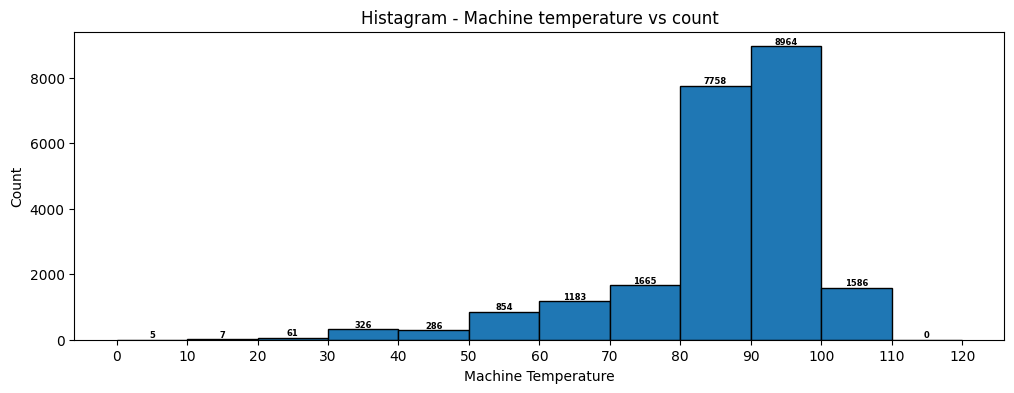

In [340]:
# Histagram
bin_size = range(0, 121, 10)
plt.figure(figsize=(12, 4))
value_count, baredge, bar = plt.hist(df['value'], bins=bin_size, edgecolor='black')

for c, edge, bar_ in zip(value_count, baredge, bar):
    plt.text(
        bar_.get_x() + bar_.get_width() / 2,
        bar_.get_height(),
        int(c),
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold',
        color='black',
    )
plt.xlabel('Machine Temperature')
plt.ylabel('Count')
plt.xticks(bin_size)
plt.title('Histagram - Machine temperature vs count')
plt.show()

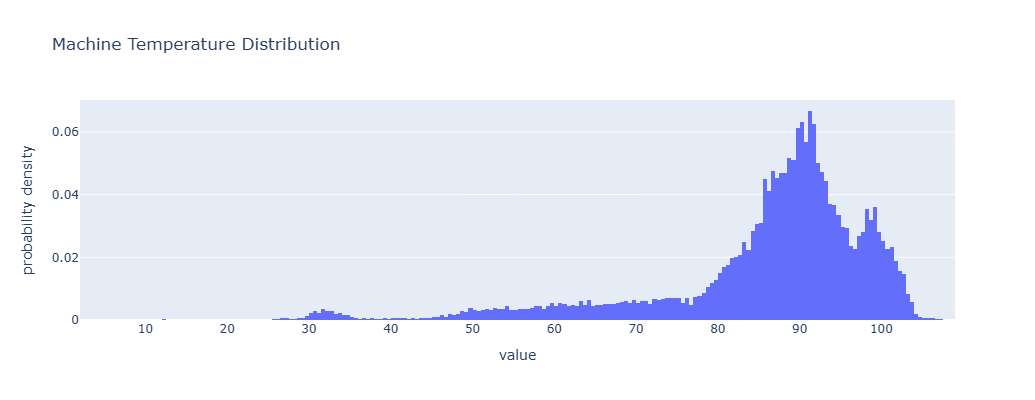

In [341]:
fig = px.histogram(df,
                   x='value', 
                   width=1000,
                   height=400,
                   histnorm="probability density",
                   title='Machine Temperature Distribution'
                  )
fig.update_xaxes(tickmode='array',
                 tickvals=list(range(0, 121, 10)),
                )
fig.show()

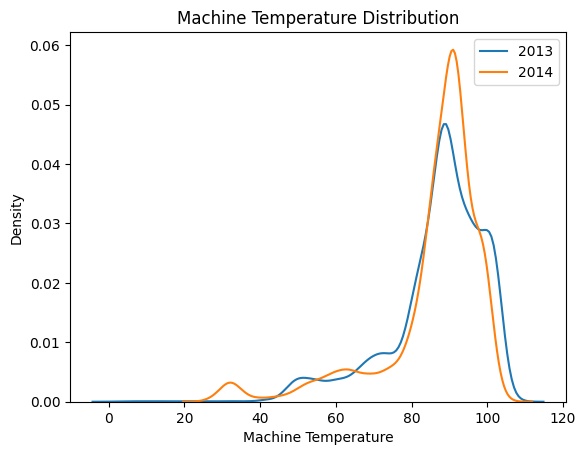

In [342]:
sns.kdeplot(df.loc[df['year']==2013, 'value'], label='2013')
sns.kdeplot(df.loc[df['year']==2014, 'value'], label='2014')

plt.xlabel('Machine Temperature')
plt.legend()
plt.title('Machine Temperature Distribution')
plt.show()

Majority of temperature is around 80~100 degree

### Anomaly Detection
**Why LSTM**  
Machine temperature is a time series data(sequence data). LSTM can be used for the prediction of sequence data with RNN architecture. LSTM has memory cells to save the information from previous time stamps, making it predict the next time stamp with previous time stanmp data.  

**How to do anomaly detection**  
Calculate threshold from training data. Flag as anomaly if residual between actual value and prediction is higher than threshold.

**Many to One approach**  
Instead of using raw data for prediction directly, we use a few past time stamps all together (historical context) for the prediction of the next time stamp (many to one style).  


#### LSTM Flow
- Set seed generator
- Train and test split
- Preprocessing the data
- Create sequences
- Convert to tensor
- Build up LSTM model
- Train LSTM with training set
- Prediction
- Threshold definition
- Anomaly detection
- Evaluation

In [343]:
df

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0
...,...,...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5,0,0
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10,0,0
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15,0,0
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20,0,0


In [344]:
df[df['timestamp'] < "2013-12-10 06:25:00.000000"]

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0
...,...,...,...,...,...,...,...,...,...,...
2122,2013-12-10 06:05:00,56.058465,2013-12-10 06:05:00,2013,12,10,6,5,0,0
2123,2013-12-10 06:10:00,56.185182,2013-12-10 06:10:00,2013,12,10,6,10,0,0
2124,2013-12-10 06:15:00,55.598353,2013-12-10 06:15:00,2013,12,10,6,15,0,0
2125,2013-12-10 06:20:00,56.157917,2013-12-10 06:20:00,2013,12,10,6,20,0,0


#### Set seed generator

In [345]:
def set_seed(seed):
    """
    Set seed generator the same for reproducibility

    Argument:
    seed -- seed number
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

#### Train and test split
Training set only contains normal period: LSTM is trained with normal period and make the prediction based on normal period.  
Note: LSTM will chase abnormal pattern if it is trained with abnormal period

Normal period: Before the 1st anomaly window

In [346]:
# Use period: before the 1st anomaly window
# split_point = 20
def train_test_split_(data, split_point):
    """
    Split the input data into training set and test set

    Argument:
    data -- Input dataframe
    split point -- Split point to divide into training and test set

    Return
    df_train -- Dataframe contains training set
    df_test -- Dataframe contains test set
    """
    df_train = data.iloc[: split_point]
    df_test = data.iloc[split_point:]

    return df_train, df_test

In [347]:
# df_train, df_test = train_test_split_(data=df, split_point=2000)

In [348]:
# print(f'Training size: {len(df_train)}')
# print(f'Test size: {len(df_test)}')

In [349]:
# df_train

#### Preprocessing the data

In [350]:
def preprocessing(data_training, data_test):
    """
    Normalize the data

    Argument:
    data_training -- Input dataframe for training
    data_test -- Input dataframe for testing

    Return:
    temps_train_scaled -- Normalized temperature value of training set (numpy ndarray)
    temps_test_scaled -- Normalized temperature value of test set (numpy ndarray)
    """
    temps_train = data_training['value'].values.reshape(-1, 1)
    temps_test = data_test['value'].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    temps_train_scaled = scaler.fit_transform(temps_train)
    temps_test_scaled = scaler.transform(temps_test)
    
    return temps_train_scaled, temps_test_scaled

In [351]:
# temps_train_scaled, temps_test_scaled = preprocessing(data_training=df_train, data_test=df_test)

In [352]:
# temps_train_scaled[: 13]

#### Create sequences
Use 12 time stamps for one sequence

In [353]:
def create_sequences(data, window_size):
    '''
    Create sequence data and store in the list

    Argument:
    data -- Normalized machine temperature value (numpy)
    window_size -- How many time stamps to use for the prediction of the next time stamp

    Return:
    X -- A list that stores many sub-sequences. Each subsequence contains t ~ t + window_size - 1
    y -- Actual value of the next time stamp. Each actual value is from t + window_size
    '''
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i: i + window_size])
        y.append(data[i + window_size])

    X = np.array(X)  # Convert X from list to numpy. Then we can convert to tensor faster later
    y = np.array(y)  # Convert X from list to numpy. Then we can convert to tensor faster later
    return X, y

In [354]:
# window_size = 12
# X_train, y_train = create_sequences(data=temps_train_scaled, window_size=window_size)
# X_test, y_test = create_sequences(data=temps_test_scaled, window_size=window_size)

In [355]:
# print(X_train[0 : 2])
# print(f'The size of X_train: {len(X_train)}')

# print(y_train[0 : 2])
# print(f'The size of y_train: {len(y_train )}')

In [356]:
# print(f'The size of X_test: {len(X_test)}')
# print(f'The size of y_test: {len(y_test)}')

#### Convert to tensor

In [357]:
def convert_to_tensor(data):
    """
    Convert numpy ndarray to tensor

    Argument:
    data -- Training/ Test sequence data (numpy ndarray)

    Return:
    data_tensor -- Data in tensor format
    
    """
    data_tensor = torch.tensor(data, dtype=torch.float32)

    return data_tensor

In [358]:
# X_train = convert_to_tensor(X_train)
# y_train = convert_to_tensor(y_train)
# X_test = convert_to_tensor(X_test)
# y_test = convert_to_tensor(y_test)

In [359]:
# print(f'Type of X_train: {type(X_train)}')
# print(f'Type of y_train: {type(y_train)}')

# print(f'Type of X_test: {type(X_test)}')
# print(f'Type of y_test: {type(y_test)}')

#### Build up LSTM model

In [360]:
class LSTMModel(nn.Module):
    '''
    Define LSTM architecture (1 input element --> 32 hidden units (learned features))
    Define fully connected layer (32 learned features --> 1 predicted output)
    Run LSTM model for forward prop with the last time stamp to get predicted output

    Argument:

    Return
    out -- Predicted output
    '''
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,  # Only take 1 time stamp data
            hidden_size=32,  # After LSTM, a has 32 learned features
            batch_first=True  # (data_size, time_stamp, features). E.g. [2125, 12, 32]
        )

        self.fc = nn.Linear(
            in_features=32,
            out_features=1  # Only predict machine temperature
        )

    def forward(self, x):
        out, _ = self.lstm(x)  # out = [data size, time stamp, learned features]
        out = out[:, -1, :]  # Only use the last output
        out = self.fc(out)

        return out

# # Trial run
# a = nn.LSTM(
#             input_size=1,
#             hidden_size=32,
#             batch_first=True  # (batch_size, time_stamp, features)
#         )    

# b = nn.Linear(
#     in_features=32,
#     out_features=1  # Only predict machine temperature
# )
# out, _ = a(X_train)
# print(out.shape)  # [2000, 12, 32]
# out = out[:, -1, :]
# pred = b(out)
# print(pred.shape)  # [2000, 1] means 2000 predicted value

#### Train LSTM with training set

In [361]:
def train_lstm_model(lstmmodel, X, y, learning_rate):
    """
    Train LSTM model

    Argument:
    lstmmodel -- The instance of LSTM model
    X -- Input X data from training set
    y -- Actual y data from training set
    learning_rate -- Learning rate for gradient descent

    Return:
    loss -- Loss function per epoch

    """

    model = lstmmodel
    
    # Define cost function
    criterion = nn.MSELoss()
    
    # Define gradient descent
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    losses = []
    model.train()
    epochs = 100
    for e in range(epochs + 1):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()  # Zero the old gradient
        loss.backward()  # Calculate the current gradient
        optimizer.step()  # Do one step gradient descent
    
        if e % 5 == 0:
            losses.append(loss.item())
            print(f'The loss function of {e} cycle: {loss:.4f}')
    plt.figure(figsize=(4, 4))
    plt.plot(losses)
    plt.xlabel('Epochs')
    plt.ylabel('Loss value')
    plt.title('Loss value over epochs')
    plt.show()
    return losses, model

In [362]:
# losses, model = train_lstm_model(lstmmodel=LSTMModel(), X=X_train, y=y_train, learning_rate=0.001)

#### Prediction

In [363]:
def lstm_pred(model, x1, x2):
    """
    LSTM for prediction

    Argument:
    model -- Trained LSTM model
    x1 -- Input X from training set
    x2 -- Input X from test set

    Return:
    train_pred -- Predicted y for training set
    test_pred -- Predicted y for test set
    """
    model.eval()  # Turn off dropout and batchnorm
    
    with torch.no_grad():
        train_pred = model(x1)
        test_pred = model(x2)
    return train_pred, test_pred

In [364]:
# train_pred, test_pred = lstm_pred(model=model, x1=X_train, x2=X_test)

In [365]:
# print(f'The shape of train_pred: {train_pred.shape}')
# print(f'The shape of test_pred: {test_pred.shape}')

# print(f'The shape of y_train: {y_train.shape}')
# print(f'The shape of y_test: {y_test.shape}')

In [366]:
# print(train_pred)
# print(test_pred)

#### Threshold definition
Threshold calculated by training data:  
- residual = (actual value - predicted value).abs()  
- mean = residual.mean()  
- std = residual.std()  
- threshold = mean + 3 std

In [367]:
def calculate_threshold(value_actual, value_pred):
    """
    Calculate the threshold to flag anomaly point

    Argument:
    value_actual -- Actual value from training set
    value_pred -- Predicted value from training set

    Return:
    threshold -- A value used to flag the anomaly point

    """

    residual = torch.abs(value_actual - value_pred).numpy()
    mean = residual.mean()
    std = residual.std()
    threshold = mean + 3 * std

    return threshold

In [368]:
# threshold = calculate_threshold(value_actual=y_train, value_pred=train_pred)

In [369]:
# print(f'Residual from training:\n{residual}')
# print(f'Residual mean from training: {mean:.4f}')
# print(f'Residual std from training: {std:.4f}')
# print(f'Threshold from training: {threshold:.4f}')

#### Anomaly detection
Flag as anomaly when residual is higher than threshold

In [370]:
def anomaly_detection(value_actual, value_pred, window_size, threshold, df):
    """
    Used to detect the anomaly points

    Arguments:
    value_actual -- Actual value from test set
    value_pred -- Predicted value from test set
    window_size -- How many time stamps to use for the prediction of the next time stamp
    threshold -- A value used to flag the anomaly point
    df -- Test set dataframe

    Return:
    df_test_for_flag -- Test dataframe with anomaly detection column
    """
    residual_test = torch.abs(value_actual - value_pred).numpy()
    anomaly_flag = residual_test > threshold
    
    df_test_for_flag = df.iloc[window_size:].copy()
    
    df_test_for_flag['Actual_scaled'] = value_actual
    df_test_for_flag['Predicted_scaled'] = value_pred
    df_test_for_flag['Error'] = residual_test
    
    df_test_for_flag['Anomaly flag'] = anomaly_flag
    df_test_for_flag['Anomaly flag'] = df_test_for_flag['Anomaly flag'].apply(lambda x: 1 if x == True else 0)

    return df_test_for_flag

In [371]:
# df_test_for_flag = anomaly_detection(value_actual=y_test, value_pred=test_pred, window_size=window_size, threshold=threshold)

In [372]:
# df_test_for_flag

In [373]:
def lstm_anomaly_detection(seed, data, split_point, window_size, lstmmodel, learning_rate):
    """
    End-to-End LSTM model for anomaly detection
    (0) Set seed generator
    (1) Train test split
    (2) Normalization
    (3) Create sequence data
    (4) Convert to tensor
    (5) LSTM model training
    (6) Prediction
    (7) Threshold calculation
    (8) Anomaly detection

    Argument:
    data -- Input dataframe
    split_point -- Split point to divide into training and test set
    window_size -- How many time stamps to use for the prediction of the next time stamp
    lstmmodel -- The instance of LSTM model
    learning_rate -- Learning rate for gradient descent

    Return:
    df_test_for_flag -- Dataframe contains flagged anomaly
    """
    # Set seed generator
    set_seed(seed)
    
    # Train test split
    df_train, df_test = train_test_split_(data, split_point)

    # Normalization
    temps_train_scaled, temps_test_scaled = preprocessing(df_train, df_test)

    # Create sequence data
    X_train, y_train = create_sequences(data=temps_train_scaled, window_size=window_size)
    X_test, y_test = create_sequences(data=temps_test_scaled, window_size=window_size)
    
    # Convert to tensor
    X_train = convert_to_tensor(X_train)
    y_train = convert_to_tensor(y_train)
    X_test = convert_to_tensor(X_test)
    y_test = convert_to_tensor(y_test)
    
    # LSTM model training
    losses, model = train_lstm_model(lstmmodel, X=X_train, y=y_train, learning_rate=learning_rate)
    
    # Prediction
    train_pred, test_pred = lstm_pred(model=model, x1=X_train, x2=X_test)
    
    # Threshold calculation
    threshold = calculate_threshold(y_train, train_pred)
    
    # Anomaly detection
    df_test_for_flag = anomaly_detection(y_test, test_pred, window_size, threshold, df=df_test)

    return df_train, df_test_for_flag

#### Evaluation

In [374]:
def eval_report(data):
    '''
    Show the evaluation result (classification report and confusion matrix)

    Argument:
    data -- Input dataframe
    
    Return:
    
    '''
    actual = data['anomaly_window']
    pred = data['Anomaly flag']
    
    # classification report
    class_report = classification_report(actual, pred)
    print(class_report)
    # confusion matrix
    conf_matrix = confusion_matrix(actual, pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(data=conf_matrix,
                cmap='Blues',
                annot=True,
                fmt='d'
               )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [375]:
def plot_temp_trend(data_whole, data_train, data_anomaly):
    '''
    (1) Plot machine temperature trend chart
    (2) Plot training set
    (3) Mark true anomaly point and window in the chart
    (4) Mark predicted anomaly in the chart

    Argument:
    data_whole -- The whole dataframe
    data_train -- Dataframe with training set only
    data_anomaly -- Dataframe with anomaly detected in test set

    Return:
    
    '''
    fig = go.Figure()

    # Plot temperature trend
    fig.add_trace(go.Scatter(x=data_whole['time'],
                             y=data_whole['value'],
                             name='Actual value'
                            )
                 )

    # Plot training set
    fig.add_trace(go.Scatter(x=data_train['time'],
                             y=data_train['value'],
                             name='Training set'
                            )
                 )
    
    # Mark anomaly and window in the chart
    df_anomaly_points = data_anomaly[data_anomaly['anomaly_point']==1]
    df_anomaly_windows = data_anomaly[data_anomaly['anomaly_window']==1]
    
    fig.add_trace(go.Scatter(x=df_anomaly_windows['time'],
                             y=df_anomaly_windows['value'],
                             mode='markers',
                             marker=dict(size=4,color='orange',symbol='circle'),
                             name='anomaly window'
                            )
                 )

    fig.add_trace(go.Scatter(x=df_anomaly_points['time'], 
                             y=df_anomaly_points['value'],
                             mode='markers',
                             marker=dict(size=6,color='red',symbol='circle'),
                             name='anomaly'
                            )
                 )

    # Mark predicted anomaly in the chart
    df_anomaly_flag = data_anomaly[data_anomaly['Anomaly flag']==1]
    fig.add_trace(go.Scatter(x=df_anomaly_flag['time'],
                             y=df_anomaly_flag['value'],
                             mode='markers',
                             marker=dict(size=4,color='grey',symbol='circle'),
                             name='Flagged anomaly'
                            )
                 )
    fig.update_layout(template='simple_white',
                      font=dict(size=14),
                      xaxis_title='Time',
                      yaxis_title='Temperature',
                      width=800,
                      height=400,
                      title='LSTM - Anomaly detection'
                     )
    fig.show()

In [376]:
# The 1st chosen normal period: Before the 1st anomaly window with 2000 time stamps
data_1 = df
split_point_1 = 2000
window_size = 12
lstmmodel_1 = LSTMModel()
learning_rate = 0.001
seed = 42

# The 2nd chosen normal period: Between 2nd and 3rd anomaly window with 9000 time stamps 
# 2013-12-20 19:00:00 ~ 2014-01-21 08:00:00
start_point = 5100
split_point_2 = 9000
data_2 = df[df.index >= start_point]
lstmmodel_2 = LSTMModel()

The loss function of 0 cycle: 0.9815
The loss function of 5 cycle: 0.9245
The loss function of 10 cycle: 0.8649
The loss function of 15 cycle: 0.7993
The loss function of 20 cycle: 0.7231
The loss function of 25 cycle: 0.6309
The loss function of 30 cycle: 0.5179
The loss function of 35 cycle: 0.3844
The loss function of 40 cycle: 0.2451
The loss function of 45 cycle: 0.1391
The loss function of 50 cycle: 0.1060
The loss function of 55 cycle: 0.1174
The loss function of 60 cycle: 0.1122
The loss function of 65 cycle: 0.0912
The loss function of 70 cycle: 0.0806
The loss function of 75 cycle: 0.0771
The loss function of 80 cycle: 0.0712
The loss function of 85 cycle: 0.0632
The loss function of 90 cycle: 0.0575
The loss function of 95 cycle: 0.0527
The loss function of 100 cycle: 0.0475


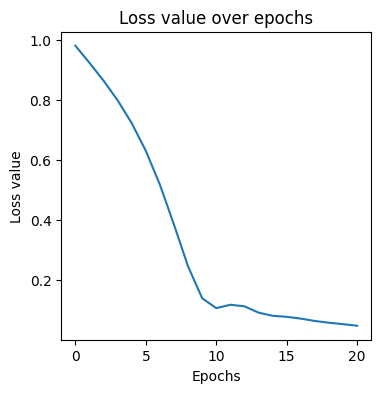

In [377]:
df_train_1, df_test_for_flag_1 = lstm_anomaly_detection(seed, data_1, split_point_1, window_size, lstmmodel_1, learning_rate)

In [378]:
df_train_1

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0
...,...,...,...,...,...,...,...,...,...,...
1995,2013-12-09 19:30:00,61.576646,2013-12-09 19:30:00,2013,12,9,19,30,0,0
1996,2013-12-09 19:35:00,60.941027,2013-12-09 19:35:00,2013,12,9,19,35,0,0
1997,2013-12-09 19:40:00,59.972307,2013-12-09 19:40:00,2013,12,9,19,40,0,0
1998,2013-12-09 19:45:00,61.658307,2013-12-09 19:45:00,2013,12,9,19,45,0,0


In [379]:
df_test_for_flag_1

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window,Actual_scaled,Predicted_scaled,Error,Anomaly flag
2012,2013-12-09 20:55:00,57.970162,2013-12-09 20:55:00,2013,12,9,20,55,0,0,-2.576890,-2.028532,0.548358,0
2013,2013-12-09 21:00:00,58.306287,2013-12-09 21:00:00,2013,12,9,21,0,0,0,-2.538091,-2.040234,0.497857,0
2014,2013-12-09 21:05:00,59.777115,2013-12-09 21:05:00,2013,12,9,21,5,0,0,-2.368316,-2.042455,0.325861,0
2015,2013-12-09 21:10:00,58.916624,2013-12-09 21:10:00,2013,12,9,21,10,0,0,-2.467641,-2.027363,0.440278,0
2016,2013-12-09 21:15:00,57.915416,2013-12-09 21:15:00,2013,12,9,21,15,0,0,-2.583209,-2.030884,0.552325,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5,0,0,2.065092,1.265442,0.799650,1
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10,0,0,2.021086,1.265234,0.755852,1
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15,0,0,1.943899,1.270405,0.673494,1
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20,0,0,2.050253,1.273516,0.776737,1


The loss function of 0 cycle: 0.9961
The loss function of 5 cycle: 0.9492
The loss function of 10 cycle: 0.9038
The loss function of 15 cycle: 0.8571
The loss function of 20 cycle: 0.8058
The loss function of 25 cycle: 0.7452
The loss function of 30 cycle: 0.6687
The loss function of 35 cycle: 0.5691
The loss function of 40 cycle: 0.4465
The loss function of 45 cycle: 0.3261
The loss function of 50 cycle: 0.2446
The loss function of 55 cycle: 0.2148
The loss function of 60 cycle: 0.2130
The loss function of 65 cycle: 0.1923
The loss function of 70 cycle: 0.1647
The loss function of 75 cycle: 0.1484
The loss function of 80 cycle: 0.1359
The loss function of 85 cycle: 0.1213
The loss function of 90 cycle: 0.1085
The loss function of 95 cycle: 0.0983
The loss function of 100 cycle: 0.0880


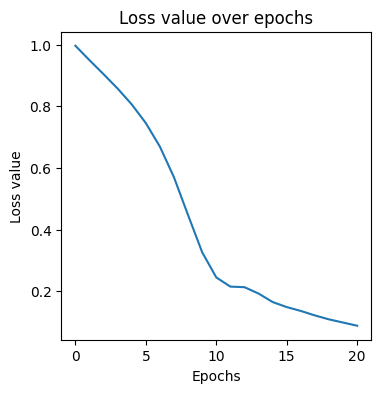

In [380]:
df_train_2, df_test_for_flag_2 = lstm_anomaly_detection(seed, data_2, split_point_2, window_size, lstmmodel_2, learning_rate)

In [381]:
df_train_2

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
5100,2013-12-20 14:15:00,100.265703,2013-12-20 14:15:00,2013,12,20,14,15,0,0
5101,2013-12-20 14:20:00,100.077963,2013-12-20 14:20:00,2013,12,20,14,20,0,0
5102,2013-12-20 14:25:00,99.017117,2013-12-20 14:25:00,2013,12,20,14,25,0,0
5103,2013-12-20 14:30:00,97.444474,2013-12-20 14:30:00,2013,12,20,14,30,0,0
5104,2013-12-20 14:35:00,98.845637,2013-12-20 14:35:00,2013,12,20,14,35,0,0
...,...,...,...,...,...,...,...,...,...,...
14095,2014-01-20 18:50:00,84.376086,2014-01-20 18:50:00,2014,1,20,18,50,0,0
14096,2014-01-20 18:55:00,84.842087,2014-01-20 18:55:00,2014,1,20,18,55,0,0
14097,2014-01-20 19:00:00,86.634401,2014-01-20 19:00:00,2014,1,20,19,0,0,0
14098,2014-01-20 19:05:00,86.579505,2014-01-20 19:05:00,2014,1,20,19,5,0,0


In [382]:
df_test_for_flag_2

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window,Actual_scaled,Predicted_scaled,Error,Anomaly flag
14112,2014-01-20 20:15:00,89.737272,2014-01-20 20:15:00,2014,1,20,20,15,0,0,0.166481,0.134288,0.032193,0
14113,2014-01-20 20:20:00,89.420028,2014-01-20 20:20:00,2014,1,20,20,20,0,0,0.123869,0.159894,0.036025,0
14114,2014-01-20 20:25:00,89.455660,2014-01-20 20:25:00,2014,1,20,20,25,0,0,0.128655,0.172131,0.043477,0
14115,2014-01-20 20:30:00,89.444188,2014-01-20 20:30:00,2014,1,20,20,30,0,0,0.127114,0.180145,0.053032,0
14116,2014-01-20 20:35:00,90.413597,2014-01-20 20:35:00,2014,1,20,20,35,0,0,0.257326,0.180135,0.077190,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5,0,0,1.301243,1.081969,0.219274,0
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10,0,0,1.250033,1.094553,0.155481,0
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15,0,0,1.160213,1.103299,0.056914,0
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20,0,0,1.283974,1.101380,0.182595,0


              precision    recall  f1-score   support

           0       0.92      0.76      0.83     18415
           1       0.20      0.50      0.29      2268

    accuracy                           0.73     20683
   macro avg       0.56      0.63      0.56     20683
weighted avg       0.85      0.73      0.77     20683



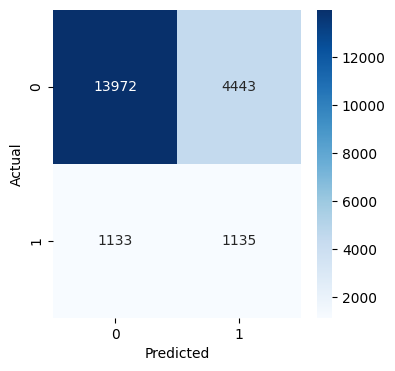

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7449
           1       0.64      0.74      0.68      1134

    accuracy                           0.91      8583
   macro avg       0.80      0.84      0.82      8583
weighted avg       0.92      0.91      0.91      8583



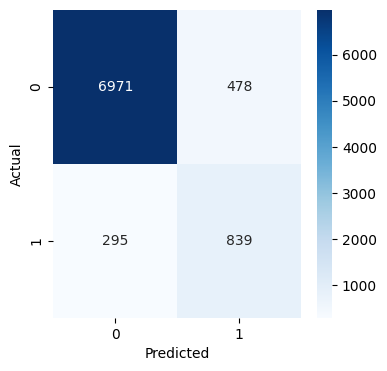

In [383]:
eval_report(data=df_test_for_flag_1)
eval_report(data=df_test_for_flag_2)

In [384]:
plot_temp_trend(data_whole=df, data_train=df_train_1, data_anomaly=df_test_for_flag_1)
plot_temp_trend(data_whole=df, data_train=df_train_2, data_anomaly=df_test_for_flag_2)

**Observation**  
- Chosen normal period: Before the 1st anomaly window
    - LSTM trained with chosen normal period (before the 1st anomaly window) flags too many normal points (high false positive)
      - precision = 0.2
      - recall = 0.5
      - f1 score = 0.29
    - The temperature level of chosen normal period seems relatively lower than the future baseline (the future normal period is higher than the chosen normal period in general)
    - Suspect that LSTM learns from chosen normal period and thinks too high value correlating to anomaly. Thus, many relatively high value points are classified as anomaly
- Chosen normal period: Between 2nd and 3rd anomaly window
  - LSTM trained with future baseline indeed can flag anomaly with fewer false positive
    - precision = 0.64
    - recall = 0.74
    - f1 score = 0.68
  - Anomaly pattern at 3rd anomaly window is different from 4th anomaly window, causing some false negative